# Adaptive Re-Fanout Analysis — with the hardened synthesizer as the default final query

Visual analysis of the **Adaptive Re-Fanout Experiment** (`adaptive_refanout_v1`, **C3**). The loop, each round, fans out $k=4$ persona-conditioned queries, searches, and an LLM judge scores the *retrieved evidence*; a controller approves (synthesize from that round) when coverage $\ge \tau$, else regenerates the whole fan-out from feedback and retries, capped at `max_rounds=6`. $\tau=3$ = loop **off**; $\tau=5$ = **full persistence**.

**We now treat the hardened synthesis prompt (`SYNTHESIS_PROMPT_HARDENED_V2`) as the default final query** — it infers the user's latent intent and applies persona constraints, while a grounding guard keeps every claim traceable to the evidence. Every block below uses this synthesizer over $\tau \in \{3,4,5\}$ (evidence held fixed per $\tau$, 72 paired query/persona pairs, single seed, `gemini-3.5-flash`). The **previous conservative final query** appears only at the end, as the comparison that motivated the change.

### Question
With a synthesizer that actually exploits the evidence, does the re-fanout loop now move the **answer** — or does it still only move **retrieval**?

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.labelweight": "bold",
    "figure.titlesize": 15, "figure.titleweight": "bold",
})

cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    PROJECT_ROOT = os.path.dirname(cwd)
elif os.path.exists(os.path.join(cwd, "outputs/adaptive_refanout_v1")):
    PROJECT_ROOT = cwd
else:
    curr = cwd
    while curr != os.path.dirname(curr):
        if os.path.exists(os.path.join(curr, "outputs/adaptive_refanout_v1")):
            PROJECT_ROOT = curr; break
        curr = os.path.dirname(curr)
D = os.path.join(PROJECT_ROOT, "outputs/adaptive_refanout_v1")

front = pd.read_csv(os.path.join(D, "synth_tau_frontier.csv"))        # {baseline, v2} x tau
gains = pd.read_csv(os.path.join(D, "v2synth_tau_gains.csv"))          # v2 paired tau diffs
improve = pd.read_csv(os.path.join(D, "synth_improve_by_tau.csv"))     # v2 - baseline, per tau
V2 = front[front["synth"] == "v2"].sort_values("tau")
BASE = front[front["synth"] == "baseline"].sort_values("tau")
NA_NOTE = "3/216 v2 answer-quality scores dropped (judge emitted invalid JSON); means use the rest."
print("loaded:", len(front), "frontier rows |", len(gains), "gain rows |", len(improve), "improve rows")
print("DEFAULT final query = SYNTHESIS_PROMPT_HARDENED_V2 |", NA_NOTE)

loaded: 6 frontier rows | 54 gain rows | 54 improve rows
DEFAULT final query = SYNTHESIS_PROMPT_HARDENED_V2 | 3/216 v2 answer-quality scores dropped (judge emitted invalid JSON); means use the rest.


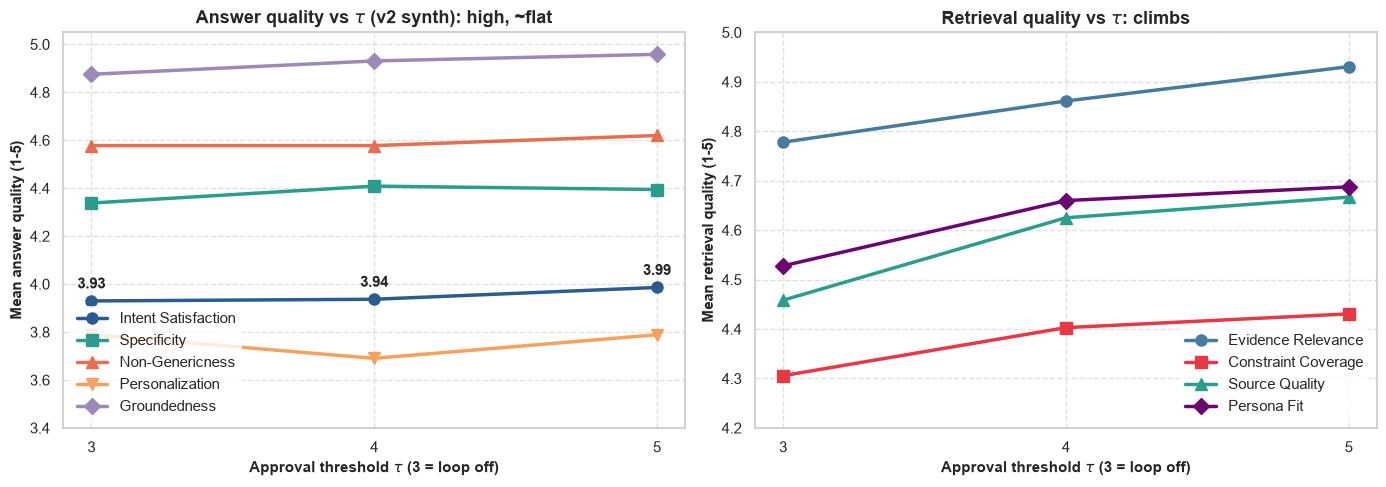

In [2]:
# === Fig 1 (v2 default): does the answer climb with tau, like retrieval does? ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tau = V2["tau"]; xt = [3, 4, 5]

ans = [("final_intent_satisfaction_mean", "Intent Satisfaction", "o", "#2b5c8f"),
       ("final_specificity_mean", "Specificity", "s", "#2a9d8f"),
       ("final_non_genericness_mean", "Non-Genericness", "^", "#e76f51"),
       ("final_personalization_target_use_mean", "Personalization", "v", "#f4a261"),
       ("final_groundedness_mean", "Groundedness", "D", "#9c89b8")]
for col, lab, mk, c in ans:
    axes[0].plot(tau, V2[col], marker=mk, lw=2.5, ms=8, label=lab, color=c)
for t, v in zip(tau, V2["final_intent_satisfaction_mean"]):
    axes[0].annotate(f"{v:.2f}", (t, v), textcoords="offset points", xytext=(0, 9), ha="center", weight="bold")
axes[0].set_xticks(xt); axes[0].set_xlabel(r"Approval threshold $\tau$ (3 = loop off)")
axes[0].set_ylabel("Mean answer quality (1-5)")
axes[0].set_title("Answer quality vs $\\tau$ (v2 synth): high, ~flat")
axes[0].set_ylim(3.4, 5.05); axes[0].legend(frameon=True, facecolor="white", edgecolor="none")
axes[0].grid(True, linestyle="--", alpha=0.6)

ret = [("retrieval_evidence_relevance_mean", "Evidence Relevance", "o", "#457b9d"),
       ("retrieval_constraint_coverage_mean", "Constraint Coverage", "s", "#e63946"),
       ("retrieval_source_quality_mean", "Source Quality", "^", "#2a9d8f"),
       ("retrieval_result_persona_fit_mean", "Persona Fit", "D", "#6a0572")]
for col, lab, mk, c in ret:
    axes[1].plot(tau, V2[col], marker=mk, lw=2.5, ms=8, label=lab, color=c)
axes[1].set_xticks(xt); axes[1].set_xlabel(r"Approval threshold $\tau$ (3 = loop off)")
axes[1].set_ylabel("Mean retrieval quality (1-5)")
axes[1].set_title("Retrieval quality vs $\\tau$: climbs")
axes[1].set_ylim(4.2, 5.0); axes[1].legend(frameon=True, facecolor="white", edgecolor="none")
axes[1].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

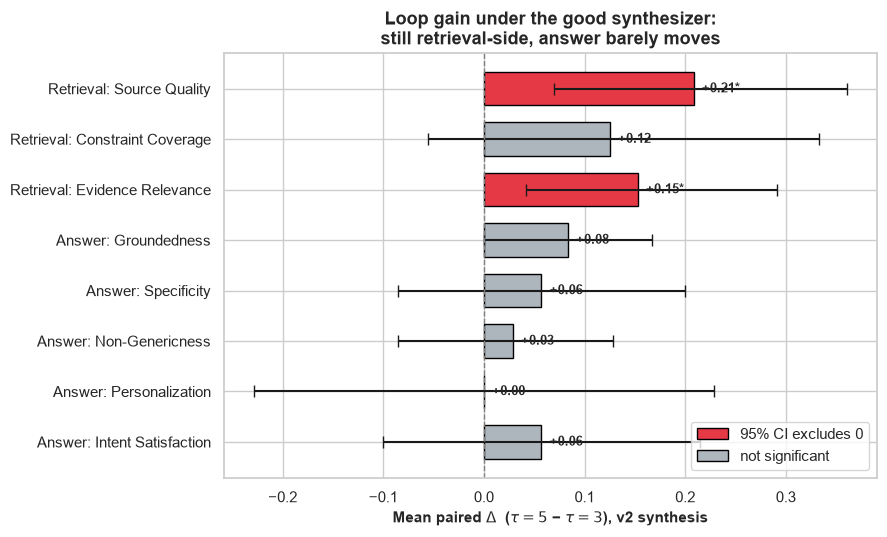

In [3]:
# === Fig 2 (v2 default): paired gain of the loop, tau=3 -> tau=5, with 95% CIs ===
order = [("retrieval_source_quality", "Retrieval: Source Quality"),
         ("retrieval_constraint_coverage", "Retrieval: Constraint Coverage"),
         ("retrieval_evidence_relevance", "Retrieval: Evidence Relevance"),
         ("final_groundedness", "Answer: Groundedness"),
         ("final_specificity", "Answer: Specificity"),
         ("final_non_genericness", "Answer: Non-Genericness"),
         ("final_personalization_target_use", "Answer: Personalization"),
         ("final_intent_satisfaction", "Answer: Intent Satisfaction")]
g = gains[gains["comparison"] == "t3_to_t5"].set_index("metric")
labels = [lab for m, lab in order]
means = np.array([g.loc[m, "mean_paired_diff"] for m, _ in order])
lo = np.array([g.loc[m, "ci95_low"] for m, _ in order]); hi = np.array([g.loc[m, "ci95_high"] for m, _ in order])
sig = (lo > 0) | (hi < 0); err = np.vstack([means - lo, hi - means])
colors = ["#e63946" if s else "#adb5bd" for s in sig]
fig, ax = plt.subplots(figsize=(9, 5.5)); y = np.arange(len(labels))
ax.barh(y, means, xerr=err, color=colors, edgecolor="black", capsize=4, height=0.66)
ax.axvline(0, color="gray", lw=1, ls="--"); ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlabel(r"Mean paired $\Delta$  ($\tau{=}5$ − $\tau{=}3$), v2 synthesis")
ax.set_title("Loop gain under the good synthesizer:\nstill retrieval-side, answer barely moves")
for yi, m, s in zip(y, means, sig):
    ax.annotate(f"{m:+.2f}" + ("*" if s else ""), (m, yi), xytext=(6 if m >= 0 else -6, 0),
                textcoords="offset points", va="center", ha="left" if m >= 0 else "right", weight="bold", size=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#e63946", edgecolor="black", label="95% CI excludes 0"),
                   Patch(facecolor="#adb5bd", edgecolor="black", label="not significant")], loc="lower right", frameon=True)
plt.tight_layout(); plt.show()

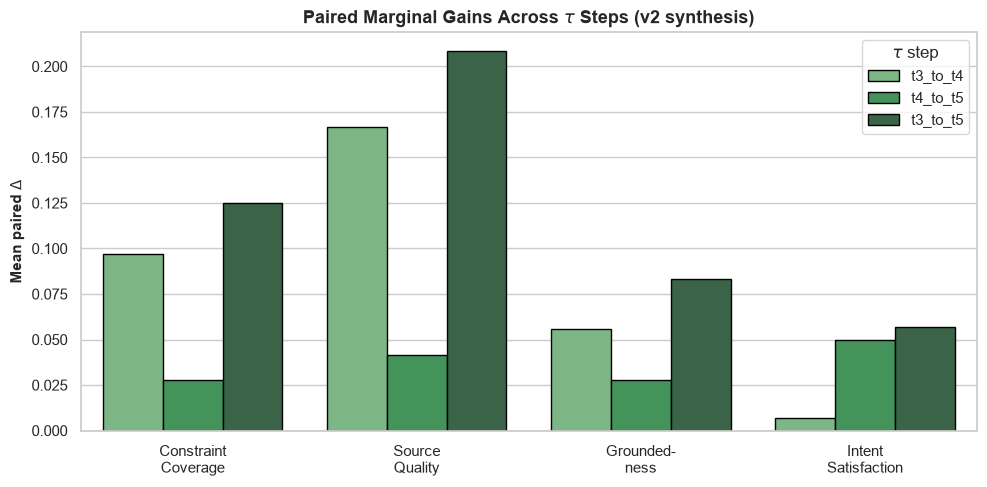

In [4]:
# === Fig 3 (v2 default): step-wise paired marginal gains across tau steps ===
key = ["t3_to_t4", "t4_to_t5", "t3_to_t5"]
mets = ["retrieval_constraint_coverage", "retrieval_source_quality", "final_groundedness", "final_intent_satisfaction"]
pretty = {"retrieval_constraint_coverage": "Constraint\nCoverage", "retrieval_source_quality": "Source\nQuality",
          "final_groundedness": "Grounded-\nness", "final_intent_satisfaction": "Intent\nSatisfaction"}
sub = gains[gains["comparison"].isin(key) & gains["metric"].isin(mets)].copy()
sub["Metric"] = sub["metric"].map(pretty)
plt.figure(figsize=(10, 5))
sns.barplot(data=sub, x="Metric", y="mean_paired_diff", hue="comparison",
            palette="Greens_d", edgecolor="black", order=[pretty[m] for m in mets], hue_order=key)
plt.axhline(0, color="gray", lw=1, ls="--"); plt.title("Paired Marginal Gains Across $\\tau$ Steps (v2 synthesis)")
plt.xlabel(""); plt.ylabel(r"Mean paired $\Delta$"); plt.legend(title="$\\tau$ step", frameon=True)
plt.tight_layout(); plt.show()

## The previous final query — what we changed, and how much it bought

The old synthesis prompt was deliberately conservative (*"do not over-personalize; be concise"*). It grounded well but under-fit the user's intent. Below: the **old** vs **new** final query at each evidence level — the change lifts the whole answer curve, and it dwarfs the $\tau$ slope.

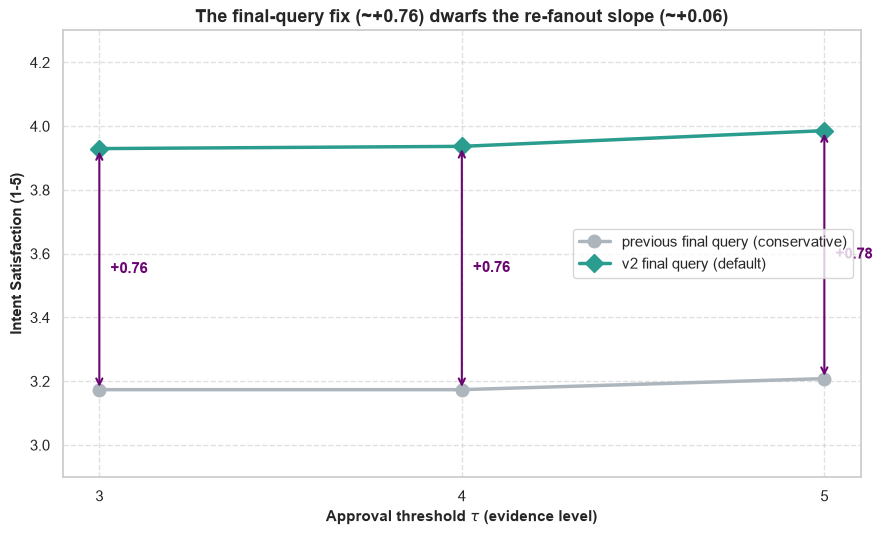

In [5]:
# === Fig 4: old vs new final query — the synthesis lift dwarfs the tau slope ===
fig, ax = plt.subplots(figsize=(9, 5.5)); xt = [3, 4, 5]
ax.plot(BASE["tau"], BASE["final_intent_satisfaction_mean"], marker="o", lw=2.5, ms=9,
        color="#adb5bd", label="previous final query (conservative)")
ax.plot(V2["tau"], V2["final_intent_satisfaction_mean"], marker="D", lw=2.5, ms=9,
        color="#2a9d8f", label="v2 final query (default)")
for t in xt:
    b = float(BASE[BASE.tau == t]["final_intent_satisfaction_mean"].iloc[0]); v = float(V2[V2.tau == t]["final_intent_satisfaction_mean"].iloc[0])
    ax.annotate("", (t, v), (t, b), arrowprops=dict(arrowstyle="<->", color="#6a0572", lw=1.5))
    ax.annotate(f"+{v-b:.2f}", (t, (b+v)/2), xytext=(8, 0), textcoords="offset points",
                color="#6a0572", weight="bold", va="center")
ax.set_xticks(xt); ax.set_xlabel(r"Approval threshold $\tau$ (evidence level)")
ax.set_ylabel("Intent Satisfaction (1-5)"); ax.set_ylim(2.9, 4.3)
ax.set_title("The final-query fix (~+0.76) dwarfs the re-fanout slope (~+0.06)")
ax.legend(frameon=True, loc="center right"); ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

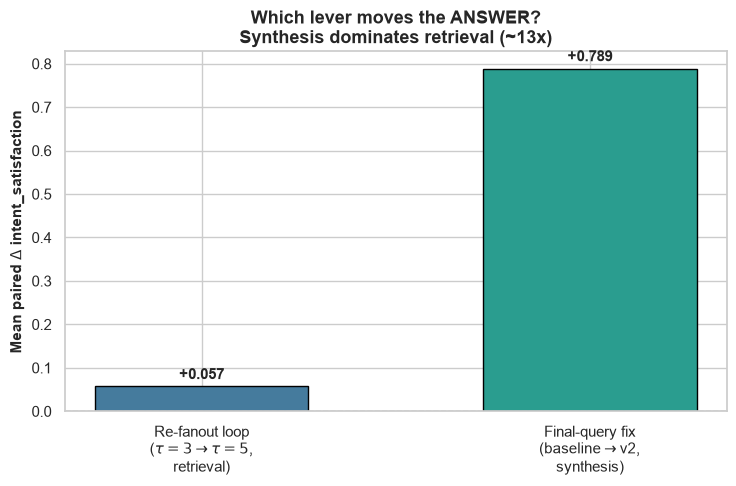

In [6]:
# === Fig 5: which lever moves the ANSWER? retrieval (re-fanout) vs synthesis (final query) ===
refan = float(gains[(gains.comparison == "t3_to_t5") & (gains.metric == "final_intent_satisfaction")]["mean_paired_diff"].iloc[0])
synth = float(improve[(improve.tau == 5) & (improve.metric == "final_intent_satisfaction")]["mean_paired_diff"].iloc[0])
labels = ["Re-fanout loop\n($\\tau{=}3\\to\\tau{=}5$,\nretrieval)", "Final-query fix\n(baseline$\\to$v2,\nsynthesis)"]
vals = [refan, synth]; colors = ["#457b9d", "#2a9d8f"]
plt.figure(figsize=(7.5, 5)); bars = plt.bar(labels, vals, color=colors, edgecolor="black", width=0.55)
plt.axhline(0, color="gray", lw=1, ls="--"); plt.ylabel(r"Mean paired $\Delta$ intent_satisfaction")
plt.title("Which lever moves the ANSWER?\nSynthesis dominates retrieval (~13x)")
for b, v in zip(bars, vals):
    plt.annotate(f"{v:+.3f}", (b.get_x()+b.get_width()/2, v), ha="center", va="bottom",
                 weight="bold", xytext=(0, 3), textcoords="offset points")
plt.tight_layout(); plt.show()

## Engaged subset — where the loop actually re-fanned ($\tau{=}5$ ran >1 round)

Only **55 of 72** pairs are ones where the $\tau{=}5$ loop did *not* approve on the first fan-out and therefore re-fanned; the other 17 approve on round 1, so re-fanout changes nothing for them. Restricting to these 55 is the fair test — *where the loop engages, does its retrieval gain reach the answer?*

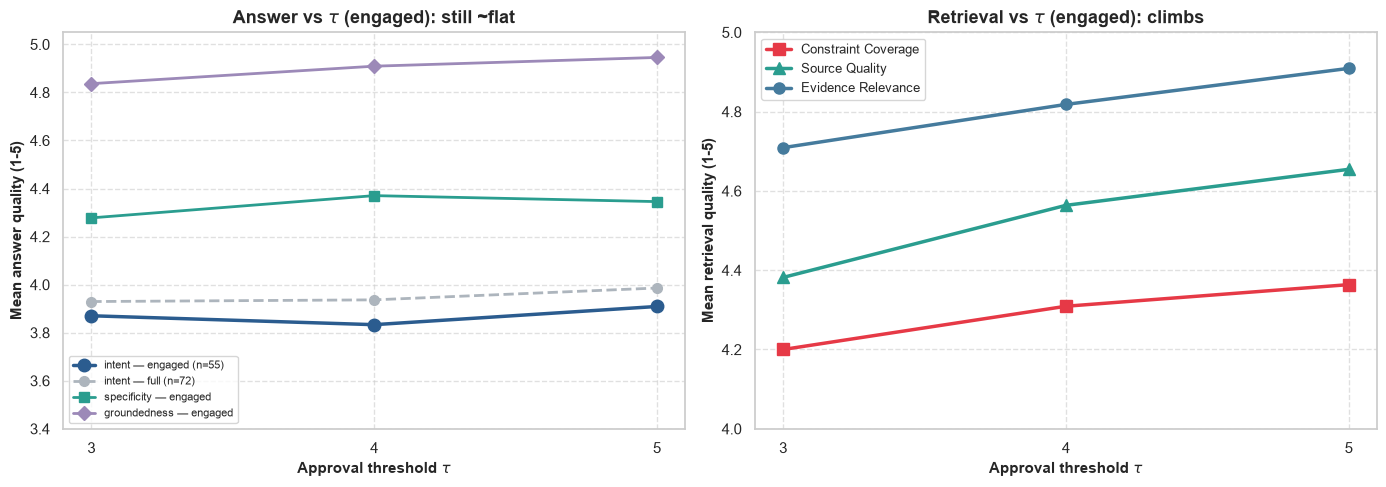

In [7]:
# === Engaged subset (n=55): answer stays flat while retrieval climbs (v2 synthesis) ===
ef = pd.read_csv(os.path.join(D, "engaged_frontier.csv"))
efc = pd.read_csv(os.path.join(D, "engaged_full_compare.csv"))
EV2 = ef[ef["synth"] == "v2"].sort_values("tau")
fig, axes = plt.subplots(1, 2, figsize=(14, 5)); xt = [3, 4, 5]

full_int = efc[efc.subset == "full"].sort_values("tau")["v2_intent"].tolist()
eng_int = efc[efc.subset == "engaged"].sort_values("tau")["v2_intent"].tolist()
axes[0].plot(xt, eng_int, marker="o", lw=2.5, ms=9, color="#2b5c8f", label="intent — engaged (n=55)")
axes[0].plot(xt, full_int, marker="o", lw=2, ms=7, ls="--", color="#adb5bd", label="intent — full (n=72)")
for col, lab, mk, c in [("final_specificity_mean", "specificity — engaged", "s", "#2a9d8f"),
                        ("final_groundedness_mean", "groundedness — engaged", "D", "#9c89b8")]:
    axes[0].plot(EV2["tau"], EV2[col], marker=mk, lw=2, ms=7, color=c, label=lab)
axes[0].set_xticks(xt); axes[0].set_xlabel(r"Approval threshold $\tau$"); axes[0].set_ylabel("Mean answer quality (1-5)")
axes[0].set_title("Answer vs $\\tau$ (engaged): still ~flat"); axes[0].set_ylim(3.4, 5.05)
axes[0].legend(fontsize=8, frameon=True); axes[0].grid(True, ls="--", alpha=0.6)

for col, lab, mk, c in [("retrieval_constraint_coverage_mean", "Constraint Coverage", "s", "#e63946"),
                        ("retrieval_source_quality_mean", "Source Quality", "^", "#2a9d8f"),
                        ("retrieval_evidence_relevance_mean", "Evidence Relevance", "o", "#457b9d")]:
    axes[1].plot(EV2["tau"], EV2[col], marker=mk, lw=2.5, ms=8, color=c, label=lab)
axes[1].set_xticks(xt); axes[1].set_xlabel(r"Approval threshold $\tau$"); axes[1].set_ylabel("Mean retrieval quality (1-5)")
axes[1].set_title("Retrieval vs $\\tau$ (engaged): climbs"); axes[1].set_ylim(4.0, 5.0)
axes[1].legend(fontsize=9, frameon=True); axes[1].grid(True, ls="--", alpha=0.6)
plt.tight_layout(); plt.show()

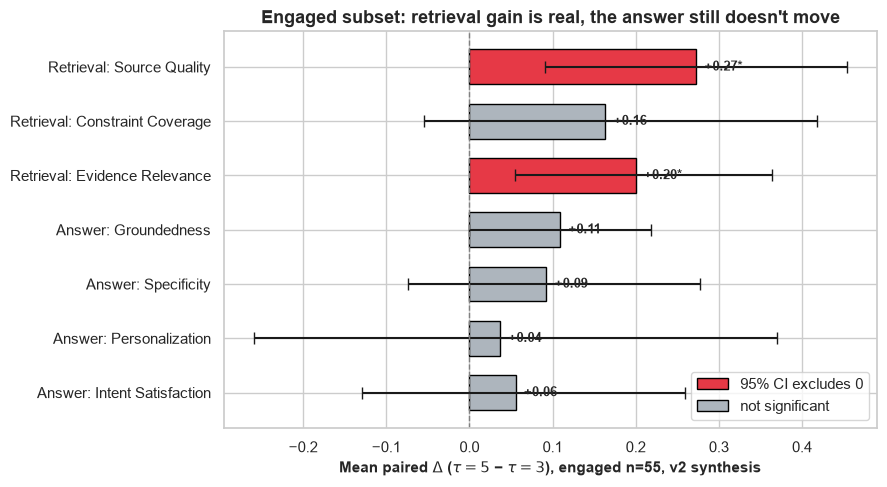

In [8]:
# === Engaged subset: paired Delta (tau=3 -> tau=5) with 95% CIs ===
eg = pd.read_csv(os.path.join(D, "engaged_v2_tau_gains.csv")).set_index("metric")
order = [("retrieval_source_quality", "Retrieval: Source Quality"),
         ("retrieval_constraint_coverage", "Retrieval: Constraint Coverage"),
         ("retrieval_evidence_relevance", "Retrieval: Evidence Relevance"),
         ("final_groundedness", "Answer: Groundedness"),
         ("final_specificity", "Answer: Specificity"),
         ("final_personalization_target_use", "Answer: Personalization"),
         ("final_intent_satisfaction", "Answer: Intent Satisfaction")]
g = eg[eg["comparison"] == "t3_to_t5"]
labels = [l for m, l in order]
means = np.array([g.loc[m, "mean_paired_diff"] for m, _ in order])
lo = np.array([g.loc[m, "ci95_low"] for m, _ in order]); hi = np.array([g.loc[m, "ci95_high"] for m, _ in order])
sig = (lo > 0) | (hi < 0); err = np.vstack([means - lo, hi - means])
colors = ["#e63946" if s else "#adb5bd" for s in sig]
fig, ax = plt.subplots(figsize=(9, 5)); y = np.arange(len(labels))
ax.barh(y, means, xerr=err, color=colors, edgecolor="black", capsize=4, height=0.64)
ax.axvline(0, color="gray", lw=1, ls="--"); ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlabel(r"Mean paired $\Delta$ ($\tau{=}5$ − $\tau{=}3$), engaged n=55, v2 synthesis")
ax.set_title("Engaged subset: retrieval gain is real, the answer still doesn't move")
for yi, m, s in zip(y, means, sig):
    ax.annotate(f"{m:+.2f}" + ("*" if s else ""), (m, yi), xytext=(6 if m >= 0 else -6, 0),
                textcoords="offset points", va="center", ha="left" if m >= 0 else "right", weight="bold", size=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#e63946", edgecolor="black", label="95% CI excludes 0"),
                   Patch(facecolor="#adb5bd", edgecolor="black", label="not significant")], loc="lower right", frameon=True)
plt.tight_layout(); plt.show()

## Pre-specified low-coverage cut — where the loop *should* help most

The fairest test of "does re-fanout help the answer where evidence was weak?" pre-specifies the subset by a **predictor judged before the loop re-fans** — the **round-1 coverage** of the first fan-out — not by the realized coverage gain (which would select on the outcome). Bands follow the in-loop judge's rubric: **weak** ($\le 3$, generic / a materially relevant constraint missing → most headroom), **mid** ($3\!<\!\cdot\!<\!5$), and **saturated** ($=5$, first fan-out already excellent → $\tau{=}5$ approves round 1, so $\tau3\equiv\tau5$ and the gain is $0$ by construction — a sanity anchor).

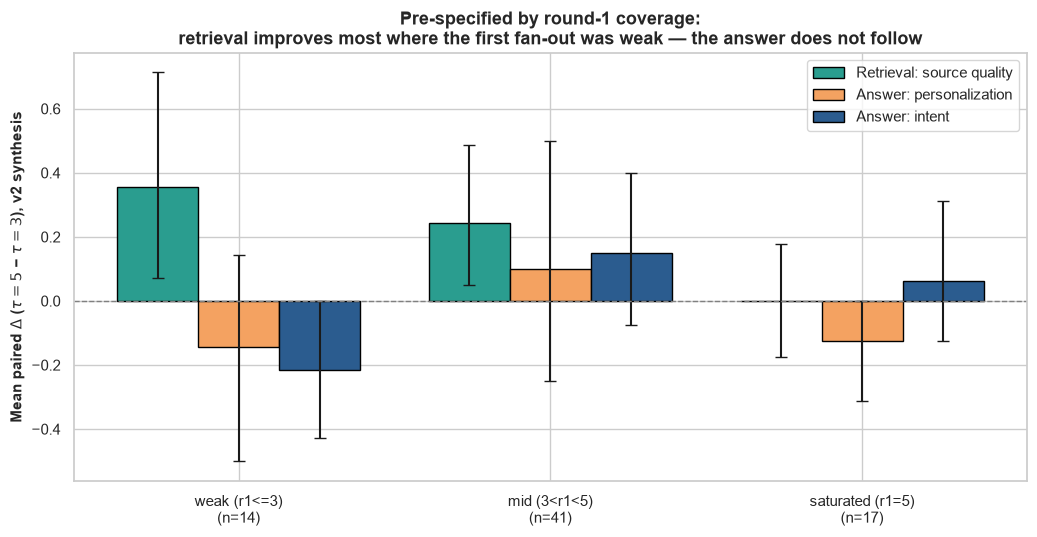

In [9]:
# === Pre-specified by round-1 coverage: retrieval gain lands where the answer gain doesn't ===
lc = pd.read_csv(os.path.join(D, "lowcov_cut.csv"))
bands = ["weak (r1<=3)", "mid (3<r1<5)", "saturated (r1=5)"]
band_n = {b: int(lc[lc.band == b]["n"].iloc[0]) for b in bands}
series = [("retrieval_source_quality", "Retrieval: source quality", "#2a9d8f"),
          ("final_personalization_target_use", "Answer: personalization", "#f4a261"),
          ("final_intent_satisfaction", "Answer: intent", "#2b5c8f")]
x = np.arange(len(bands)); w = 0.26
fig, ax = plt.subplots(figsize=(10.5, 5.5))
for i, (m, lab, c) in enumerate(series):
    sub = lc[lc.metric == m].set_index("band")
    means = np.array([sub.loc[b, "mean_paired_diff"] for b in bands])
    lo = np.array([sub.loc[b, "ci95_low"] for b in bands]); hi = np.array([sub.loc[b, "ci95_high"] for b in bands])
    ax.bar(x + (i - 1) * w, means, w, yerr=np.vstack([means - lo, hi - means]), capsize=4,
           label=lab, color=c, edgecolor="black")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xticks(x); ax.set_xticklabels([f"{b}\n(n={band_n[b]})" for b in bands])
ax.set_ylabel(r"Mean paired $\Delta$ ($\tau{=}5$ − $\tau{=}3$), v2 synthesis")
ax.set_title("Pre-specified by round-1 coverage:\nretrieval improves most where the first fan-out was weak — the answer does not follow")
ax.legend(frameon=True, loc="upper right")
plt.tight_layout(); plt.show()

**Reading it:** the loop's retrieval gain is largest in the **weak** band (+0.36 source quality, significant) — exactly where the first fan-out had the most room. But the **answer does not follow**: intent trends **−0.21** there (not up), and the only faintly-positive answer signal is in the **mid** band (+0.15, n.s.). So the honest, pre-specified cut **does not support** the intuition that re-fanout lifts the answer where evidence was weak — if anything it inverts it, consistent with broader evidence *diluting* focus on intrinsically hard queries. (Small strata — n=14 for weak — single seed; the −0.21 CI just touches 0, so read it as "no positive answer effect where the loop works hardest," not a firm negative.)

## Summary of Key Findings

With the hardened **v2 synthesizer as the default final query**, the C3 picture resolves cleanly:

1. **The good synthesizer lifts the whole answer** — intent jumps **+0.74 / +0.75 / +0.79** (baseline → v2, at $\tau=3/4/5$; all CIs exclude 0), from ~3.2 to ~3.9. Groundedness also nudges up (+0.07 at each $\tau$) — the v2 grounding guard means the gain carries **no faithfulness cost**.
2. **Re-fanout still moves retrieval, not the answer.** Under v2, going $\tau{=}3\to\tau{=}5$ climbs source-quality **+0.21\*** and constraint-coverage +0.13, but intent only **+0.057, CI $[-0.10, +0.21]$ — not significant** (Fig 2). Even with a synthesizer that exploits evidence, the loop's extra rounds don't reach the answer.
3. **Attribution (Fig 5).** The answer is driven by **synthesis (~+0.76), not re-fanout (~+0.06)** — a ~**13×** gap. There is a faint synergy (the synthesis lift grows $0.739\to0.789$ as $\tau$ rises, i.e. a good synthesizer exploits better evidence slightly more), but it is small and within noise.
4. **So what each lever is for:** the **re-fanout loop earns its keep on retrieval quality** (coverage, source quality — significant); the **final query is where answer quality is won**. They are near-orthogonal on this benchmark.
5. **Even where the loop engages** ($\tau{=}5$ ran >1 round, 55/72 pairs), the pattern holds: retrieval source-quality climbs **+0.27\*** ($\tau{=}3\to\tau{=}5$) while intent is **+0.056 (ns)**. So the decoupling is not a dilution artifact of the round-1 approvers — it survives on the loop's own turf.
6. **A pre-specified cut inverts the naive intuition.** Stratifying by round-1 coverage (a predictor, not the realized outcome), the loop's retrieval gain is *largest* where the first fan-out was weakest (**+0.36\*** source quality, weak band) — yet the answer does **not** follow there (intent **−0.21**); the only faint positive answer signal is in the mid band. Better evidence lands hardest exactly where it least helps the answer.

**Caveats.** Single seed (R=1) — the re-fanout answer null is "no *detectable* effect," not a proven zero. 3/216 v2 answer-quality scores were unscorable (judge returned invalid JSON) and are excluded. Cost is out of scope (all $\tau$ share their evidence's cost; the synthesis ablations reuse it).